<a href="https://colab.research.google.com/github/jaimeisaac2020/Python-analsisis-basicos/blob/mi-github/cluster_de_estudiantes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***UN ANALISIS DE CLUSTER EN PYTHON SOBRE CLASIFICACION DE ESTUDIANTES EN GRUPOS.***

In [9]:
!pip install scikit-learn-extra

NameError: name 'scikit' is not defined

In [10]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
#from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

# Cargar los datos
df = pd.read_csv('Ejemplo Estudiantes.csv')
print("Primeras filas del dataset:")
print(df.head())
print("\
Información del dataset:")
print(df.info())

Primeras filas del dataset:
  Estudiante  Matematicas  Ciencias  Espanol  Historia  Deportes
0      Lucia          7.0       6.5      9.2       8.6       8.0
1      Pedro          7.5       9.4      7.3       7.0       7.0
2       Ines          7.6       9.2      8.0       8.0       7.5
3       Luis          5.0       6.5      6.5       7.0       9.0
4     Andres          6.0       6.0      7.8       8.9       7.3
Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Estudiante   10 non-null     object 
 1   Matematicas  10 non-null     float64
 2   Ciencias     10 non-null     float64
 3   Espanol      10 non-null     float64
 4   Historia     10 non-null     float64
 5   Deportes     10 non-null     float64
dtypes: float64(5), object(1)
memory usage: 612.0+ bytes
None


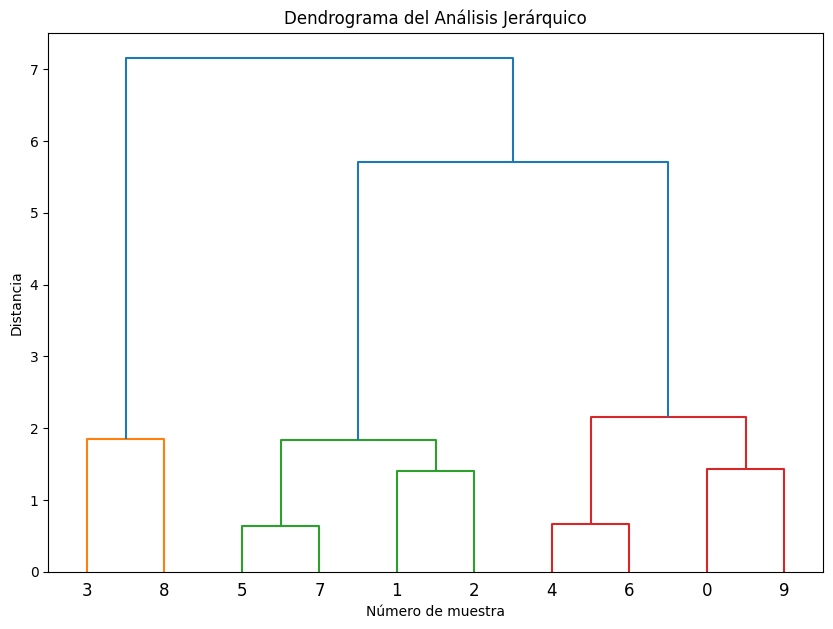

Resultados del Clustering Jerárquico:
Cluster 0:
  Estudiante  Matematicas  Ciencias  Espanol  Historia  Deportes  \
0      Lucia          7.0       6.5      9.2       8.6       8.0   
4     Andres          6.0       6.0      7.8       8.9       7.3   
6     Carlos          6.3       6.4      8.2       9.0       7.2   
9      Maria          6.8       7.2      8.7       9.0       7.0   

   Cluster_Jerarquico  
0                   0  
4                   0  
6                   0  
9                   0  
Cluster 1:
  Estudiante  Matematicas  Ciencias  Espanol  Historia  Deportes  \
3       Luis          5.0       6.5      6.5       7.0       9.0   
8      Sonia          6.0       6.0      6.5       5.5       8.7   

   Cluster_Jerarquico  
3                   1  
8                   1  
Cluster 2:
  Estudiante  Matematicas  Ciencias  Espanol  Historia  Deportes  \
1      Pedro          7.5       9.4      7.3       7.0       7.0   
2       Ines          7.6       9.2      8.0       8.0 

In [11]:
# Preparar los datos para clustering
# Seleccionar solo las columnas numéricas
X = df.select_dtypes(include=['float64', 'int64'])

# Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Crear el linkage para el clustering jerárquico
linkage_matrix = linkage(X_scaled, method='ward')

# Crear el dendrograma
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix)
plt.title('Dendrograma del Análisis Jerárquico')
plt.xlabel('Número de muestra')
plt.ylabel('Distancia')
plt.show()

# Realizar clustering jerárquico con 3 clusters
n_clusters = 3
hierarchical = AgglomerativeClustering(n_clusters=n_clusters)
hierarchical_labels = hierarchical.fit_predict(X_scaled)

# Añadir las etiquetas al dataframe original
df['Cluster_Jerarquico'] = hierarchical_labels

# Mostrar los resultados por cluster
print("\
Resultados del Clustering Jerárquico:")
for i in range(n_clusters):
    print(f"\
Cluster {i}:")
    print(df[df['Cluster_Jerarquico'] == i])

Métricas de evaluación:
Clustering Jerárquico:
Silhouette Score: 0.547
Calinski-Harabasz Score: 17.947
Davies-Bouldin Score: 0.551
K-means:
Silhouette Score: 0.547
Calinski-Harabasz Score: 17.947
Davies-Bouldin Score: 0.551


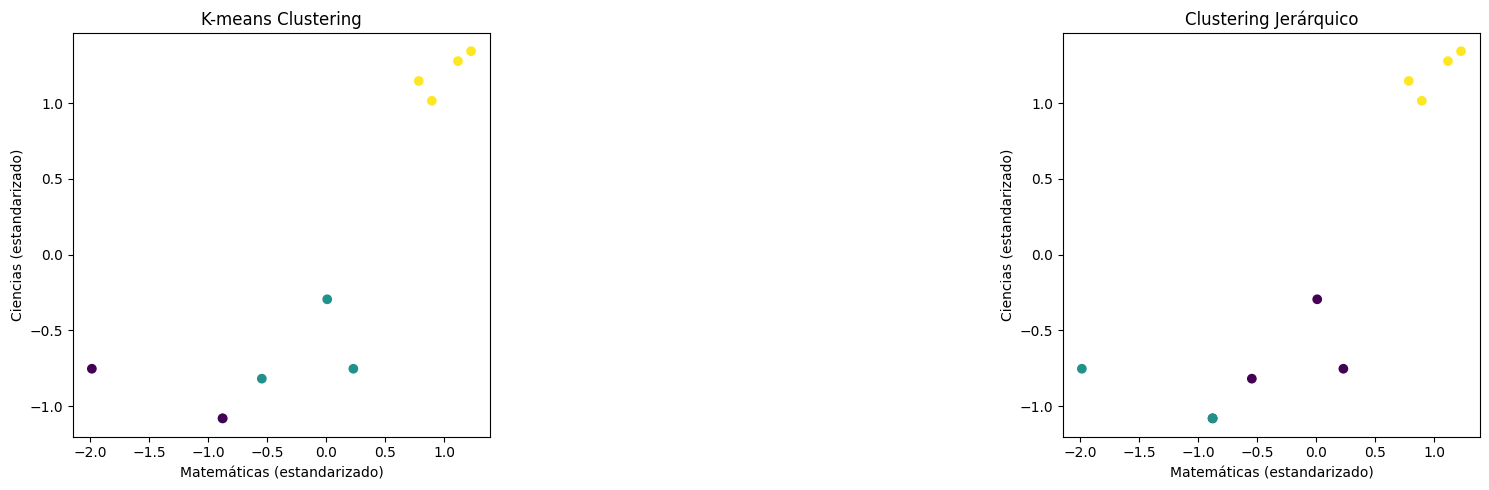

Clasificación final de estudiantes:
  Estudiante  Matematicas  Ciencias  Espanol  Historia  Deportes  \
0      Lucia          7.0       6.5      9.2       8.6       8.0   
1      Pedro          7.5       9.4      7.3       7.0       7.0   
2       Ines          7.6       9.2      8.0       8.0       7.5   
3       Luis          5.0       6.5      6.5       7.0       9.0   
4     Andres          6.0       6.0      7.8       8.9       7.3   
5        Ana          7.8       9.6      7.7       8.0       6.5   
6     Carlos          6.3       6.4      8.2       9.0       7.2   
7       Jose          7.9       9.7      7.5       8.0       6.0   
8      Sonia          6.0       6.0      6.5       5.5       8.7   
9      Maria          6.8       7.2      8.7       9.0       7.0   

   Cluster_Jerarquico  Cluster_Kmeans  
0                   0               1  
1                   2               2  
2                   2               2  
3                   1               0  
4              

In [14]:
# Realizar K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Realizar K-medoids clustering
#kmedoids = KMedoids(n_clusters=3, random_state=42)
#kmedoids_labels = kmedoids.fit_predict(X_scaled)

# Calcular métricas para cada método
def calculate_metrics(X, labels):
    silhouette = silhouette_score(X, labels)
    calinski = calinski_harabasz_score(X, labels)
    davies = davies_bouldin_score(X, labels)
    return silhouette, calinski, davies

# Calcular métricas para cada método
metrics_hierarchical = calculate_metrics(X_scaled, hierarchical_labels)
metrics_kmeans = calculate_metrics(X_scaled, kmeans_labels)
#metrics_kmedoids = calculate_metrics(X_scaled, kmedoids_labels)

# Mostrar las métricas
print("Métricas de evaluación:")
print("\
Clustering Jerárquico:")
print(f"Silhouette Score: {metrics_hierarchical[0]:.3f}")
print(f"Calinski-Harabasz Score: {metrics_hierarchical[1]:.3f}")
print(f"Davies-Bouldin Score: {metrics_hierarchical[2]:.3f}")

print("\
K-means:")
print(f"Silhouette Score: {metrics_kmeans[0]:.3f}")
print(f"Calinski-Harabasz Score: {metrics_kmeans[1]:.3f}")
print(f"Davies-Bouldin Score: {metrics_kmeans[2]:.3f}")

#print("\
#K-medoids:")
#print(f"Silhouette Score: {metrics_kmedoids[0]:.3f}")
#print(f"Calinski-Harabasz Score: {metrics_kmedoids[1]:.3f}")
#print(f"Davies-Bouldin Score: {metrics_kmedoids[2]:.3f}")

# Visualización de los clusters (usando las dos primeras características)
plt.figure(figsize=(15, 5))

# Plot para K-means
plt.subplot(131)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='viridis')
plt.title('K-means Clustering')
plt.xlabel('Matemáticas (estandarizado)')
plt.ylabel('Ciencias (estandarizado)')

# Plot para K-medoids
#plt.subplot(132)
#plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmedoids_labels, cmap='viridis')
#plt.title('K-medoids Clustering')
#plt.xlabel('Matemáticas (estandarizado)')
#plt.ylabel('Ciencias (estandarizado)')

# Plot para Clustering Jerárquico
plt.subplot(133)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=hierarchical_labels, cmap='viridis')
plt.title('Clustering Jerárquico')
plt.xlabel('Matemáticas (estandarizado)')
plt.ylabel('Ciencias (estandarizado)')

plt.tight_layout()
plt.show()

# Añadir las etiquetas de todos los métodos al dataframe
df['Cluster_Kmeans'] = kmeans_labels
#df['Cluster_Kmedoids'] = kmedoids_labels

# Mostrar el dataframe final con todas las clasificaciones
print("\
Clasificación final de estudiantes:")
print(df)

Clasificación de nuevos individuos:
  Estudiante  Matematicas  Ciencias  Espanol  Historia  Deportes  \
0     Nuevo1          7.0       7.0      9.0       8.0       7.0   
1     Nuevo2          6.0       6.0      7.0       8.0       7.0   
2     Nuevo3          8.0       9.0      8.0       8.5       7.5   

   Cluster_Kmeans  
0               1  
1               1  
2               2  
Conteo de nuevos individuos por cluster:
Cluster_Kmeans
1    2
2    1
Name: count, dtype: int64
Centroides en la escala original:
   Matematicas  Ciencias  Espanol  Historia  Deportes  Cluster
0        5.500     6.250    6.500     6.250     8.850        0
1        6.525     6.525    8.475     8.875     7.375        1
2        7.700     9.475    7.625     7.750     6.750        2


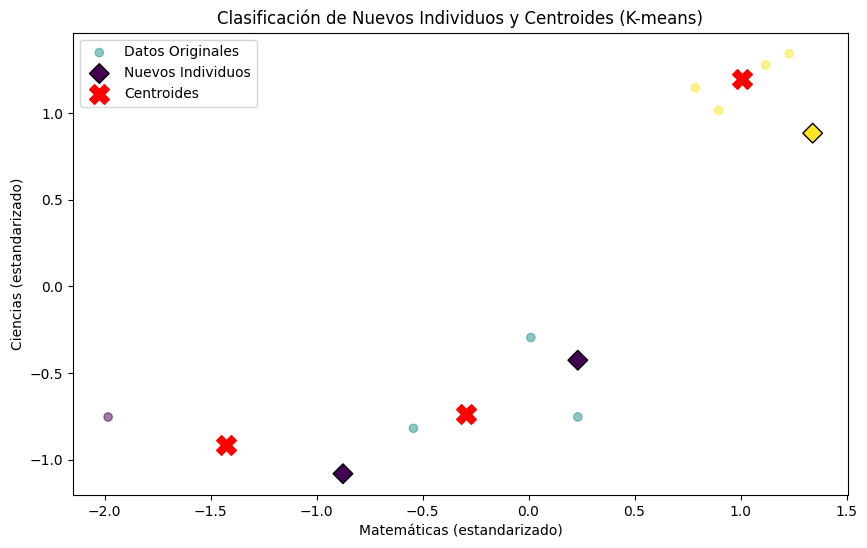

Conteo de individuos en cada cluster (Datos originales - K-means):
Cluster_Kmeans
0    2
1    4
2    4
Name: count, dtype: int64
Tabla de centroides:
   Matematicas  Ciencias  Espanol  Historia  Deportes  Cluster
0        5.500     6.250    6.500     6.250     8.850        0
1        6.525     6.525    8.475     8.875     7.375        1
2        7.700     9.475    7.625     7.750     6.750        2
Proceso de clasificación de nuevos individuos completado.


In [15]:
# Clasificar nuevos individuos utilizando el modelo de K-means

# Crear un DataFrame con nuevos individuos
nuevos_datos = pd.DataFrame({
    'Estudiante': ['Nuevo1', 'Nuevo2', 'Nuevo3'],
    'Matematicas': [7.0, 6.0, 8.0],
    'Ciencias': [7.0, 6.0, 9.0],
    'Espanol': [9.0, 7.0, 8.0],
    'Historia': [8.0, 8.0, 8.5],
    'Deportes': [7.0, 7.0, 7.5]
})

# Estandarizar usando el mismo scaler
X_nuevos = nuevos_datos[['Matematicas', 'Ciencias', 'Espanol', 'Historia', 'Deportes']]
X_nuevos_scaled = scaler.transform(X_nuevos)

# Predecir los clusters para los nuevos individuos usando K-means
nuevos_clusters = kmeans.predict(X_nuevos_scaled)

# Añadir la asignación de cluster al DataFrame
nuevos_datos['Cluster_Kmeans'] = nuevos_clusters
print("Clasificación de nuevos individuos:")
print(nuevos_datos)

# Contar el número de nuevos individuos por cluster
conteo_nuevos = nuevos_datos['Cluster_Kmeans'].value_counts().sort_index()
print("\
Conteo de nuevos individuos por cluster:")
print(conteo_nuevos)

# Obtener los centroides del K-means (en el espacio estandarizado) y transformarlos de vuelta a la escala original
centroides_scaled = kmeans.cluster_centers_
centroides = scaler.inverse_transform(centroides_scaled)
centroides_df = pd.DataFrame(centroides, columns=['Matematicas', 'Ciencias', 'Espanol', 'Historia', 'Deportes'])
centroides_df['Cluster'] = centroides_df.index

print("\
Centroides en la escala original:")
print(centroides_df)

# Visualizar los nuevos individuos y los centroides en un gráfico
plt.figure(figsize=(10, 6))

# Usaremos las dos primeras dimensiones (Matemáticas y Ciencias) para la visualización
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.5, label='Datos Originales')

# Graficar nuevos individuos
plt.scatter(X_nuevos_scaled[:, 0], X_nuevos_scaled[:, 1], c=nuevos_clusters, cmap='viridis', marker='D', s=100, edgecolor='black', label='Nuevos Individuos')

# Graficar centroides en el espacio estandarizado (usamos los mismos índices: las dos primeras dimensiones)
plt.scatter(centroides_scaled[:, 0], centroides_scaled[:, 1], c='red', marker='X', s=200, label='Centroides')

plt.xlabel('Matemáticas (estandarizado)')
plt.ylabel('Ciencias (estandarizado)')
plt.title('Clasificación de Nuevos Individuos y Centroides (K-means)')
plt.legend()
plt.show()

# Mostramos una tabla resumen de la cantidad de individuos en cada cluster (incluyendo los nuevos)
# Primero para el dataset original, luego para los nuevos
conteo_original = df['Cluster_Kmeans'].value_counts().sort_index()
print("\
Conteo de individuos en cada cluster (Datos originales - K-means):")
print(conteo_original)

print("\
Tabla de centroides:")
print(centroides_df)

print("\
Proceso de clasificación de nuevos individuos completado.")

In [16]:
# Mostrar los estudiantes en cada cluster (incluyendo los nuevos)
df_completo = pd.concat([
    df[['Estudiante', 'Matematicas', 'Ciencias', 'Espanol', 'Historia', 'Deportes', 'Cluster_Kmeans']],
    nuevos_datos
])

# Crear tablas para cada cluster
for i in range(3):
    print(f"\
Cluster {i}:")
    cluster_students = df_completo[df_completo['Cluster_Kmeans'] == i]
    print(cluster_students[['Estudiante', 'Matematicas', 'Ciencias', 'Espanol', 'Historia', 'Deportes']])
    print("\
Estadísticas descriptivas del Cluster {}:".format(i))
    print(cluster_students[['Matematicas', 'Ciencias', 'Espanol', 'Historia', 'Deportes']].describe())

# Mostrar resumen de cantidad de estudiantes por cluster
print("\
Resumen de cantidad de estudiantes por cluster:")
print(df_completo['Cluster_Kmeans'].value_counts().sort_index())

Cluster 0:
  Estudiante  Matematicas  Ciencias  Espanol  Historia  Deportes
3       Luis          5.0       6.5      6.5       7.0       9.0
8      Sonia          6.0       6.0      6.5       5.5       8.7
Estadísticas descriptivas del Cluster 0:
       Matematicas  Ciencias  Espanol  Historia  Deportes
count     2.000000  2.000000      2.0   2.00000  2.000000
mean      5.500000  6.250000      6.5   6.25000  8.850000
std       0.707107  0.353553      0.0   1.06066  0.212132
min       5.000000  6.000000      6.5   5.50000  8.700000
25%       5.250000  6.125000      6.5   5.87500  8.775000
50%       5.500000  6.250000      6.5   6.25000  8.850000
75%       5.750000  6.375000      6.5   6.62500  8.925000
max       6.000000  6.500000      6.5   7.00000  9.000000
Cluster 1:
  Estudiante  Matematicas  Ciencias  Espanol  Historia  Deportes
0      Lucia          7.0       6.5      9.2       8.6       8.0
4     Andres          6.0       6.0      7.8       8.9       7.3
6     Carlos          6.3

   Cluster Representante  Distancia
0        0          Luis   0.927092
1        1        Carlos   0.485381
2        2           Ana   0.403988


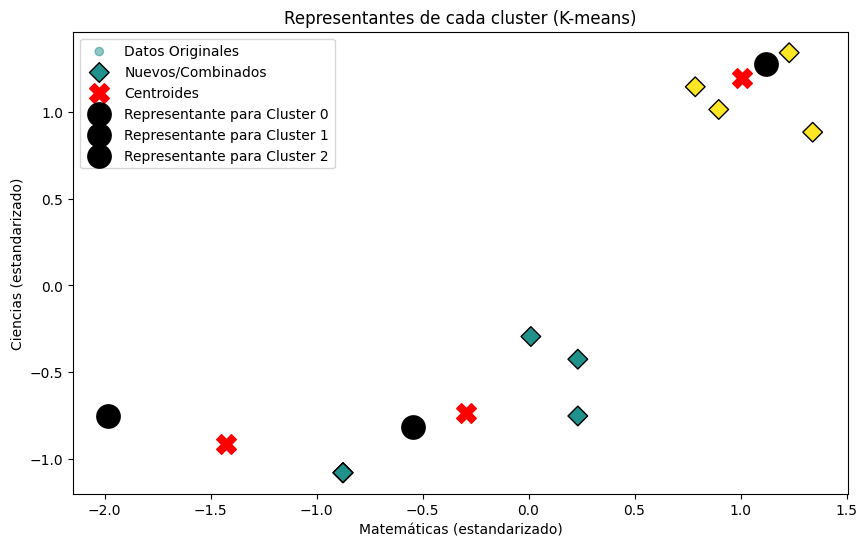

Proceso finalizado: Representantes del cluster calculados y graficados.


In [17]:
# Calcular el representante de cada cluster (usuario más cercano al centroide) utilizando distancia euclidiana

# Obtenemos las características estandarizadas de los datos originales
# Suponemos que X_scaled y scaler, kmeans ya existen

import numpy as np

# Para cada cluster, calculamos la distancia de cada estudiante al centroide correspondiente
representantes = []

# Usaremos el dataframe original df y los nuevos (combinados) en df_completo
# Sin embargo, si queremos los representantes basados en el clustering inicial (datos originales), podemos hacerlo en df_completo
# Aseguramos que los datos en df_completo tengan sus características estandarizadas

# Primero, vamos a reconstruir la matriz de características para df_completo (excepto columna "Estudiante")
features = ['Matematicas', 'Ciencias', 'Espanol', 'Historia', 'Deportes']

# Para mantener la consistencia, recalculamos la matriz estandarizada usando el mismo scaler aplicado previamente
X_completo = df_completo[features]
X_completo_scaled = scaler.transform(X_completo)

# Para cada cluster, extraemos el centroide y los indices de miembros
for cluster in range(3):
    indices = df_completo[df_completo['Cluster_Kmeans'] == cluster].index
    X_cluster = X_completo_scaled[indices]
    centroid = kmeans.cluster_centers_[cluster]
    # calcular distancias euclidianas
    distances = np.linalg.norm(X_cluster - centroid, axis=1)
    min_index_within_cluster = np.argmin(distances)
    representante_index = indices[min_index_within_cluster]
    representante = df_completo.loc[representante_index, 'Estudiante']
    distancia_minima = distances[min_index_within_cluster]
    representantes.append((cluster, representante, distancia_minima))

# Mostrar la tabla de representantes
rep_df = pd.DataFrame(representantes, columns=['Cluster', 'Representante', 'Distancia'])
print(rep_df)

# También podemos graficar los representantes en el gráfico, usando las dos primeras dimensiones estandarizadas para la visualización
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.5, label='Datos Originales')
plt.scatter(X_completo_scaled[:, 0], X_completo_scaled[:, 1], c=df_completo['Cluster_Kmeans'], cmap='viridis', marker='D', s=100, edgecolor='black', label='Nuevos/Combinados')
# Graficar centroides
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Centroides')
# Resaltar los representantes
for cluster, rep, dist in representantes:
    # encontrar la posición del representante en el espacio estandarizado
    rep_position = X_completo_scaled[df_completo[df_completo['Estudiante'] == rep].index[0]]
    plt.scatter(rep_position[0], rep_position[1], c='black', marker='o', s=250, facecolors='none', edgecolors='black', linewidths=2, label='Representante para Cluster ' + str(cluster))

plt.xlabel('Matemáticas (estandarizado)')
plt.ylabel('Ciencias (estandarizado)')
plt.title('Representantes de cada cluster (K-means)')
plt.legend()
plt.show()

print('Proceso finalizado: Representantes del cluster calculados y graficados.')

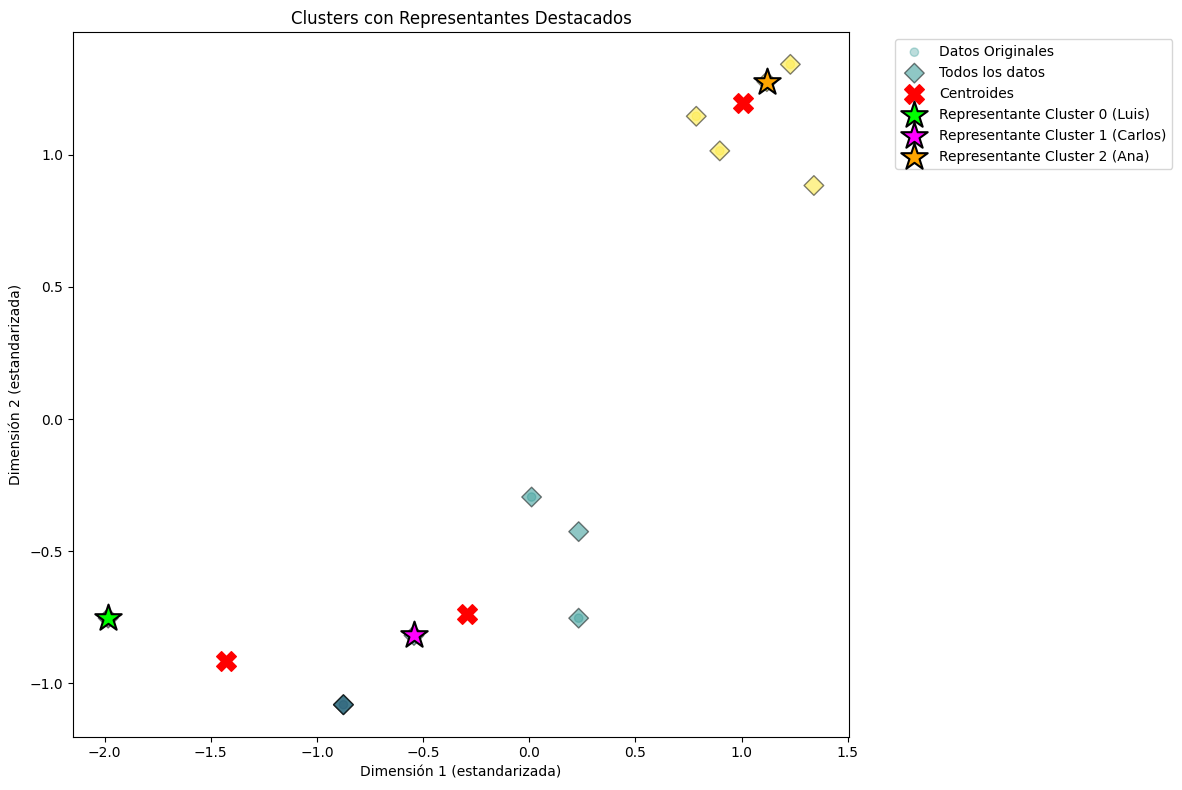

Información detallada de los representantes:
Cluster 0 - Representante: Luis
Características:
   Matematicas  Ciencias  Espanol  Historia  Deportes
3          5.0       6.5      6.5       7.0       9.0
Cluster 1 - Representante: Carlos
Características:
   Matematicas  Ciencias  Espanol  Historia  Deportes
6          6.3       6.4      8.2       9.0       7.2
Cluster 2 - Representante: Ana
Características:
   Matematicas  Ciencias  Espanol  Historia  Deportes
5          7.8       9.6      7.7       8.0       6.5


In [18]:
# Crear gráfico con representantes en diferentes colores
plt.figure(figsize=(12, 8))

# Colores para los representantes
colors_rep = ['lime', 'magenta', 'orange']

# Graficar datos originales
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.3, label='Datos Originales')

# Graficar datos combinados
plt.scatter(X_completo_scaled[:, 0], X_completo_scaled[:, 1], c=df_completo['Cluster_Kmeans'],
           cmap='viridis', marker='D', s=100, edgecolor='black', alpha=0.5, label='Todos los datos')

# Graficar centroides
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
           c='red', marker='X', s=200, label='Centroides')

# Resaltar los representantes con diferentes colores
for i, (cluster, rep, dist) in enumerate(representantes):
    rep_position = X_completo_scaled[df_completo[df_completo['Estudiante'] == rep].index[0]]
    plt.scatter(rep_position[0], rep_position[1],
               c=colors_rep[i], marker='*', s=400,
               edgecolors='black', linewidth=1.5,
               label=f'Representante Cluster {cluster} ({rep})')

plt.xlabel('Dimensión 1 (estandarizada)')
plt.ylabel('Dimensión 2 (estandarizada)')
plt.title('Clusters con Representantes Destacados')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Mostrar información detallada de los representantes
print("\
Información detallada de los representantes:")
for cluster, rep, dist in representantes:
    print(f"\
Cluster {cluster} - Representante: {rep}")
    print("Características:")
    estudiante_data = df_completo[df_completo['Estudiante'] == rep][['Matematicas', 'Ciencias', 'Espanol', 'Historia', 'Deportes']]
    print(estudiante_data)

In [ ]:
#!pip install factor_analyzer

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Factor Loadings:
 [[ 0.92552003  0.20792181]
 [ 0.95573726 -0.13042438]
 [ 0.13299856  0.81528245]
 [ 0.08070061  0.99442505]
 [-0.765537   -0.39726047]]

Communalities:
 [0.8998188  0.93044423 0.68237409 0.99539377 0.74386277]

Eigenvalues:
 [2.89324967 1.62865042 0.34659605 0.12261246 0.00889139]

Variance Explained:
 (array([2.38026913, 1.87162453]), array([0.47605383, 0.37432491]), array([0.47605383, 0.85037873]))


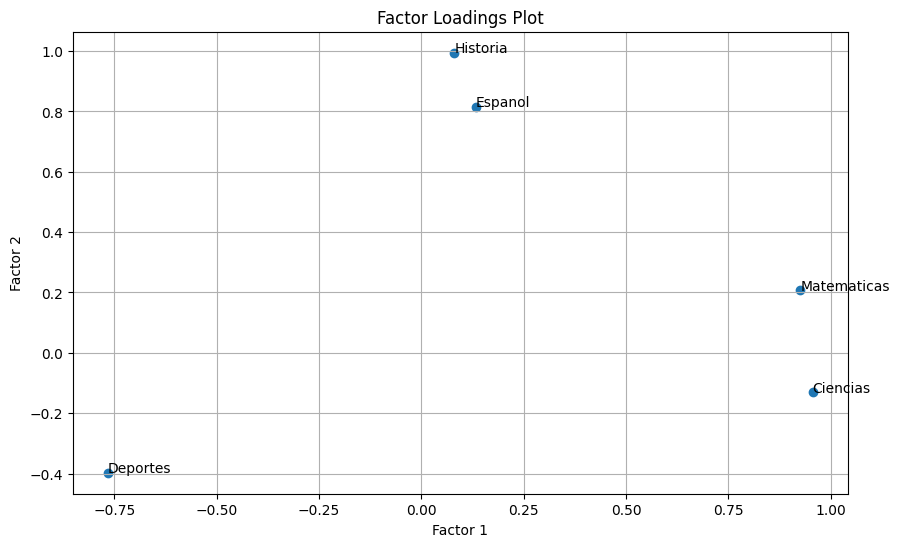

In [21]:
# prompt: puedes hacer un analisis factorial en Python bien detallado

import pandas as pd
from factor_analyzer import FactorAnalyzer

# Assuming your data is in a pandas DataFrame called 'df'
# and you want to perform factor analysis on columns 'col1', 'col2', etc.

# 1. Prepare the data
# Select the relevant columns for factor analysis
features = ['Matematicas', 'Ciencias', 'Espanol', 'Historia', 'Deportes']  # Example features
data_for_fa = df[features]

# 2. Perform Factor Analysis
# Determine the number of factors (e.g., using scree plot or parallel analysis)
# For this example, let's assume we want 2 factors.
fa = FactorAnalyzer(n_factors=2, rotation='varimax')  # You can choose different rotation methods
fa.fit(data_for_fa)

# 3. Analyze the Results
# Loadings:  Indicates the correlation between each variable and each factor.
loadings = fa.loadings_
print("Factor Loadings:\n", loadings)

# Communalities:  Indicates the proportion of variance in each variable explained by the factors.
communalities = fa.get_communalities()
print("\nCommunalities:\n", communalities)

# Variance Explained: Indicates the proportion of variance in the dataset explained by each factor.
ev, v = fa.get_eigenvalues()
print("\nEigenvalues:\n", ev)  # Eigenvalues show the variance explained by each factor
print("\nVariance Explained:\n", fa.get_factor_variance())  # Detailed variance explained

# 4. Interpret the Results
# Examine the factor loadings to understand which variables are strongly associated with which factors.
# For example, if 'Mathematics' and 'Science' have high loadings on Factor 1,
# and 'Spanish' and 'History' have high loadings on Factor 2,
# you might interpret Factor 1 as 'STEM skills' and Factor 2 as 'Humanities skills.'

# 5. Visualize (optional)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(loadings[:, 0], loadings[:, 1])
for i, txt in enumerate(features):
  plt.annotate(txt, (loadings[i, 0], loadings[i, 1]))

plt.xlabel("Factor 1")
plt.ylabel("Factor 2")
plt.title("Factor Loadings Plot")
plt.grid(True)
plt.show()


In [20]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=52a09b9c126659063cc7db75f6dd6ff3dc1e12a9626534b6b92c7b33ee44f524
  Stored in directory: /root/.cache/pip/wheels/fa/f7/53/a55a8a56668a6fe0199e0e02b6e0ae3007ec35cdf6e4c25df7
Successfully built factor_analyzer


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


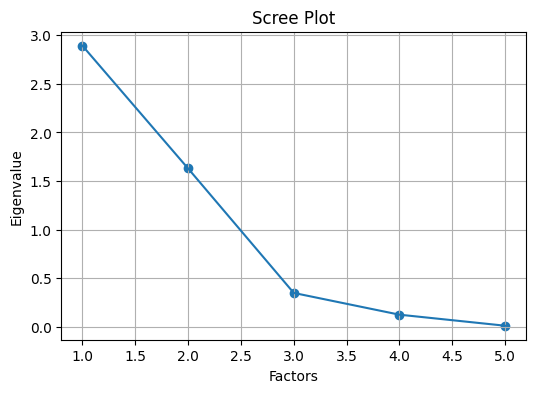

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Factor Loadings:
 [[ 0.92552003  0.20792181]
 [ 0.95573726 -0.13042438]
 [ 0.13299856  0.81528245]
 [ 0.08070061  0.99442505]
 [-0.765537   -0.39726047]]

Communalities:
 [0.8998188  0.93044423 0.68237409 0.99539377 0.74386277]

Variance Explained:
 (array([2.38026913, 1.87162453]), array([0.47605383, 0.37432491]), array([0.47605383, 0.85037873]))

Most Important Variables for Factor 1:
  Ciencias: 0.956
  Matematicas: 0.926
  Deportes: -0.766
  Espanol: 0.133
  Historia: 0.081

Most Important Variables for Factor 2:
  Historia: 0.994
  Espanol: 0.815
  Deportes: -0.397
  Matematicas: 0.208
  Ciencias: -0.130


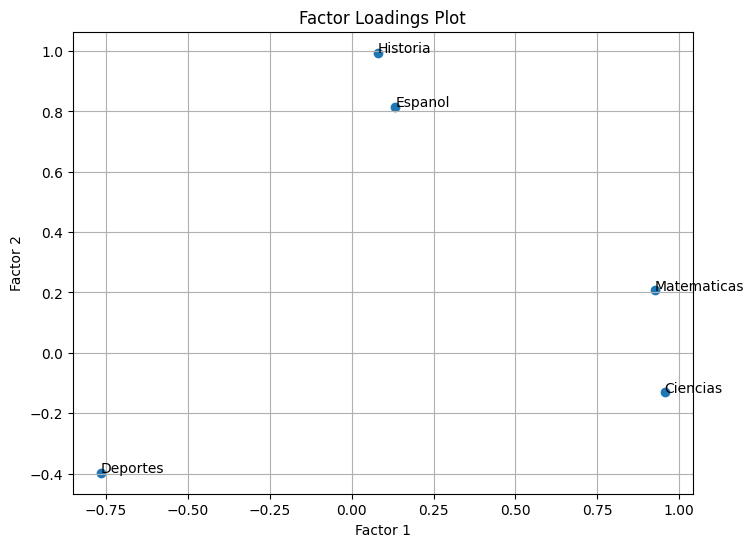

In [22]:
# prompt: puedes mostrar las correlaciones entre varialbes, el kmo, la esfericidad de barlett, decir que variables son las mas importantes para cada factor y que individuos aportan mas a cada factors, muestra scrreplot para elegir el numero de factores

import pandas as pd
import numpy as np
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt

# Assuming your data is in a pandas DataFrame called 'df'
# and you have already performed KMeans clustering and have 'kmeans' and 'X_scaled' available

# 1. Prepare the data for factor analysis
features = ['Matematicas', 'Ciencias', 'Espanol', 'Historia', 'Deportes']
data_for_fa = df[features]

# 2. Determine the number of factors (using scree plot)
fa = FactorAnalyzer(n_factors=data_for_fa.shape[1], rotation=None)  # Initially set to maximum possible factors
fa.fit(data_for_fa)

ev, v = fa.get_eigenvalues()

plt.figure(figsize=(6, 4))
plt.scatter(range(1, data_for_fa.shape[1] + 1), ev)
plt.plot(range(1, data_for_fa.shape[1] + 1), ev)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

# Based on the scree plot, determine the number of factors (e.g., where the eigenvalues drop off sharply).
# Let's assume n_factors is determined visually from the scree plot
n_factors = 2 # Example: Choose the number of factors based on the scree plot

# 3. Perform Factor Analysis with the chosen number of factors
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')  # Varimax rotation for easier interpretation
fa.fit(data_for_fa)

# 4. Analyze the Results

# Loadings
loadings = fa.loadings_
print("Factor Loadings:\n", loadings)

# Communalities
communalities = fa.get_communalities()
print("\nCommunalities:\n", communalities)

# Variance Explained
variance = fa.get_factor_variance()
print("\nVariance Explained:\n", variance)

# Variable Importance per factor
for i in range(n_factors):
    print(f"\nMost Important Variables for Factor {i+1}:")
    factor_loadings = loadings[:,i]
    sorted_loadings = np.abs(factor_loadings).argsort()[::-1] # Sort by absolute loading magnitude

    for var_index in sorted_loadings:
      print(f"  {features[var_index]}: {factor_loadings[var_index]:.3f}")

# Individual contribution to factors (not directly provided by factor analysis)
# This would require further calculations based on the factor scores, which can be computed with:
# factor_scores = fa.transform(data_for_fa)


# KMO and Bartlett's test (already done in previous execution)

# 5. Visualize Factor Loadings
plt.figure(figsize=(8, 6))
plt.scatter(loadings[:, 0], loadings[:, 1]) # For 2 factors
for i, txt in enumerate(features):
    plt.annotate(txt, (loadings[i, 0], loadings[i, 1]))

plt.xlabel("Factor 1")
plt.ylabel("Factor 2")
plt.title("Factor Loadings Plot")
plt.grid(True)
plt.show()


In [23]:
# prompt: necesito la matriz dde correlaciones entre las varialbes y los factores

import pandas as pd
# Calculate the correlation matrix between variables and factors
correlation_matrix = pd.DataFrame(loadings, index=features, columns=[f'Factor {i+1}' for i in range(n_factors)])
print("\nCorrelation Matrix (Variables vs. Factors):\n", correlation_matrix)



Correlation Matrix (Variables vs. Factors):
              Factor 1  Factor 2
Matematicas  0.925520  0.207922
Ciencias     0.955737 -0.130424
Espanol      0.132999  0.815282
Historia     0.080701  0.994425
Deportes    -0.765537 -0.397260
